## Project 2: Exploratory Data Analysis (EDA)

#### Goal: Analysis the cleaned dataset from Project 1 to understand patterns, trends, and distributions

### 1.Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Load the cleaned dataset produced in Project 1

In [2]:
df=pd.read_excel('Cleaned_Dataset_DA1.xlsx')
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Year,Month,Day
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2023,January,Wednesday
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,2024,August,Friday
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2024,February,Tuesday
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,2023,October,Sunday
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2025,May,Thursday


### 3.Dataset Overview

##### Shape

In [3]:
df.shape

(1200, 17)

##### Columns

In [4]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice', 'Year',
       'Month', 'Day'],
      dtype='str')

##### Information

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
 14  Year             1200 non-null   int64         
 15

##### Data Types

In [6]:
df.dtypes

OrderID                       str
Date               datetime64[us]
CustomerID                    str
Product                       str
Quantity                    int64
UnitPrice                 float64
ShippingAddress               str
PaymentMethod                 str
OrderStatus                   str
TrackingNumber                str
ItemsInCart                 int64
CouponCode                    str
ReferralSource                str
TotalPrice                float64
Year                        int64
Month                         str
Day                           str
dtype: object

### 4.Missing Values

In [7]:
df.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
Year               0
Month              0
Day                0
dtype: int64

### 5.Duplicate Values

In [8]:
df.duplicated().sum()

np.int64(0)

### 6.Basic Satatistics (Mean,Median,Count)

In [9]:
df.select_dtypes(include='number').agg(['mean','median','count'])

,Quantity,UnitPrice,ItemsInCart,TotalPrice,Year
mean,2.945833,356.41275,5.485,1053.9683,2023.7675
median,3.000000,364.21000,5.000,823.6150,2024.0000
count,1200.000000,1200.00000,1200.000,1200.0000,1200.0000


### 7.Numerical Data Analysis

### Quantity

In [10]:
df['Quantity'].describe().reset_index()

,index,Quantity
0,count,1200.000000
1,mean,2.945833
2,std,1.407557
3,min,1.000000
4,25%,2.000000
5,50%,3.000000
6,75%,4.000000
7,max,5.000000


### Unit Price

In [11]:
df['UnitPrice'].describe().reset_index()

,index,UnitPrice
0,count,1200.000000
1,mean,356.412750
2,std,197.177146
3,min,11.390000
4,25%,186.062500
5,50%,364.210000
6,75%,521.570000
7,max,699.930000


### ItemsInCart

In [12]:
df['ItemsInCart'].describe().reset_index()

,index,ItemsInCart
0,count,1200.000000
1,mean,5.485000
2,std,2.281983
3,min,1.000000
4,25%,4.000000
5,50%,5.000000
6,75%,7.000000
7,max,10.000000


### TotalPrice

In [13]:
df['TotalPrice'].describe().reset_index()

,index,TotalPrice
0,count,1200.000000
1,mean,1053.968300
2,std,819.856558
3,min,11.390000
4,25%,410.520000
5,50%,823.615000
6,75%,1578.475000
7,max,3456.400000


### 8.Histograms-Distribution

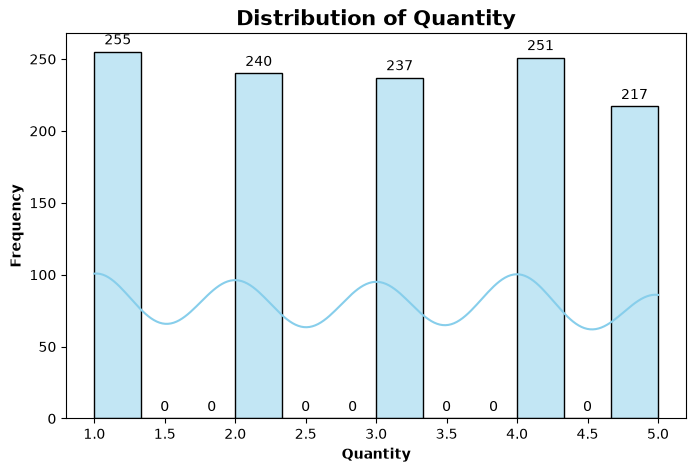

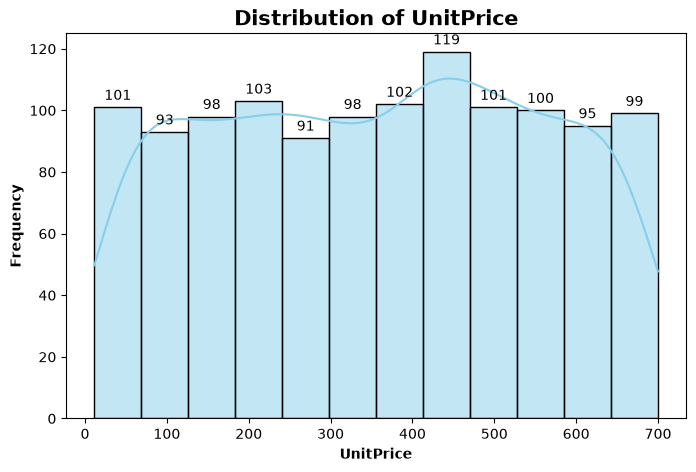

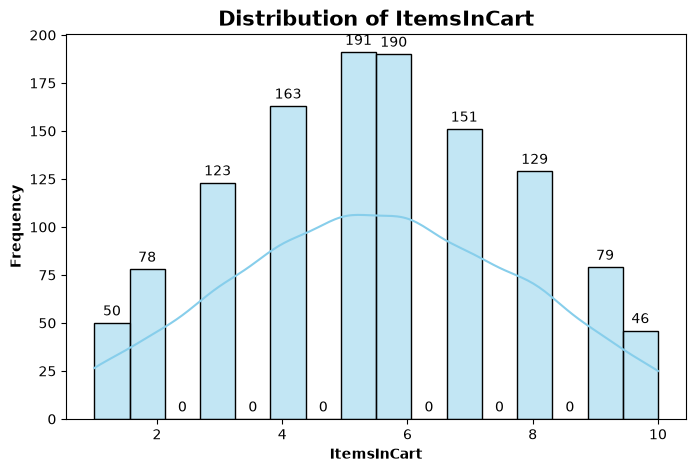

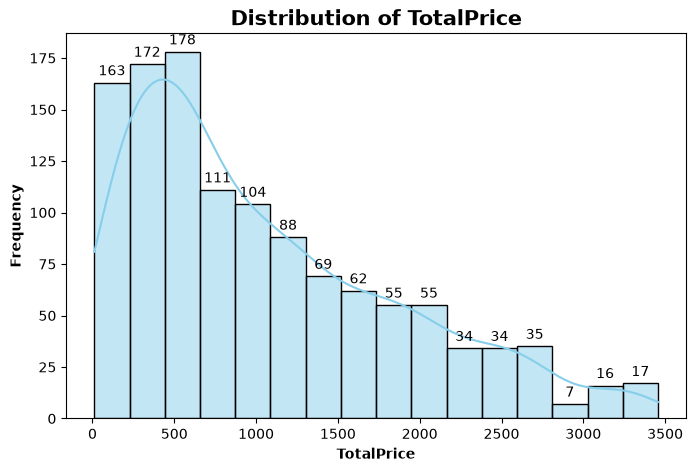

In [14]:
numeric_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

for col in numeric_cols:
    plt.figure(figsize=(8,5))
    ax=sns.histplot(df[col], kde=True,color='skyblue')

    for container in ax.containers:
        ax.bar_label(container,fmt='%d',padding=3)
        
    plt.title(f'Distribution of {col}',fontsize=15,fontweight='bold')
    plt.xlabel(col,fontweight='bold')
    plt.ylabel('Frequency',fontweight='bold')
    plt.show()

### 9.Outlier Detection

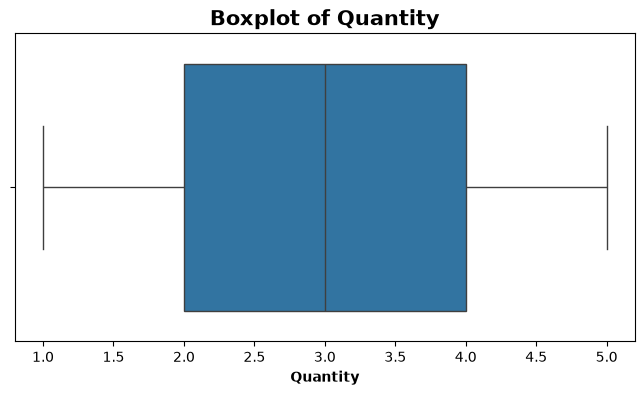

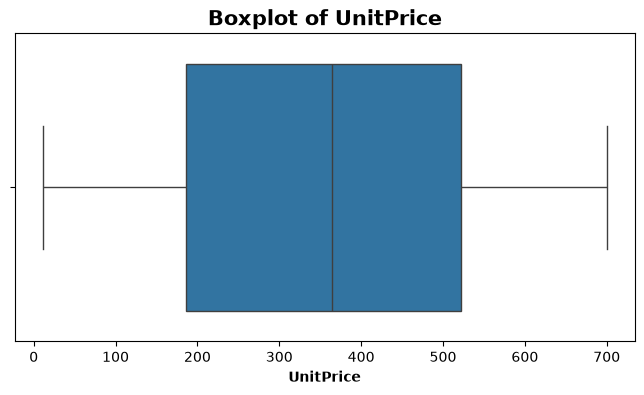

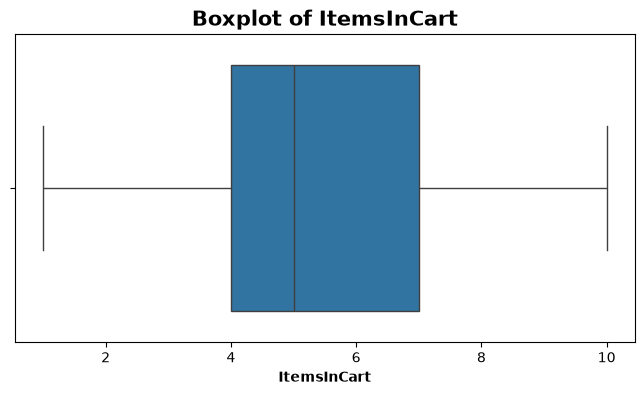

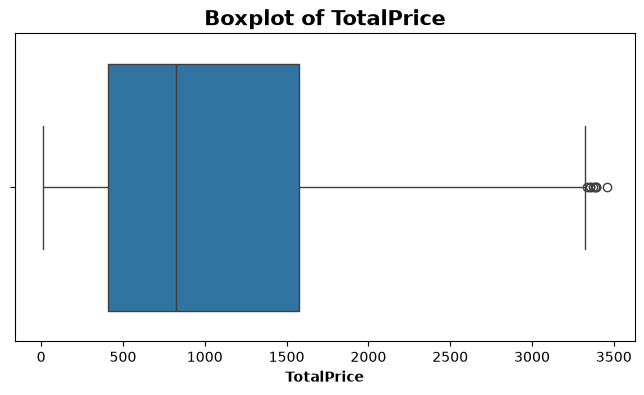

In [15]:
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}',fontsize=15,fontweight='bold')
    plt.xlabel(col,fontweight='bold')
    
    plt.show()

### 10.Product Analysis

#### Product Count

In [16]:
df['Product'].value_counts().reset_index()

,Product,count
0,Printer,181
1,Tablet,179
2,Chair,178
3,Laptop,173
4,Desk,170
5,Monitor,163
6,Phone,156


#### Product Chart

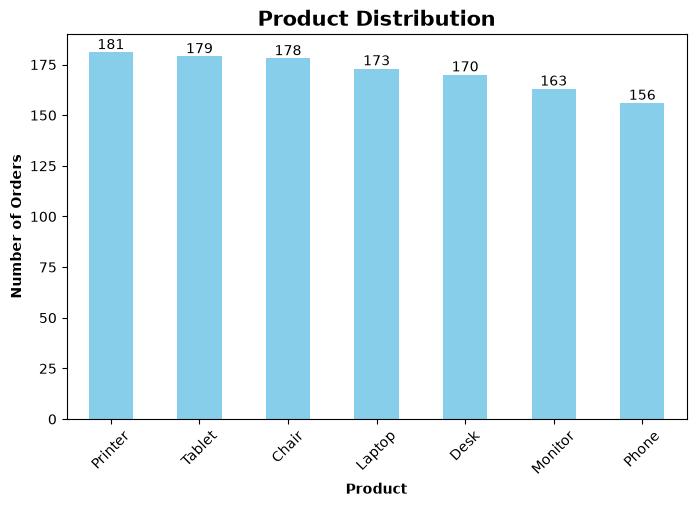

In [17]:
plt.figure(figsize=(8,5))
x=df['Product'].value_counts().plot(kind='bar',color='skyblue')
plt.bar_label(x.containers[0])
plt.title('Product Distribution',fontsize=15,fontweight='bold')
plt.xlabel('Product',fontweight='bold')
plt.ylabel('Number of Orders',fontweight='bold')
plt.xticks(rotation=45)
plt.show()

### 11.Product-wise Total Sales

In [18]:
Product_Sales=df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False).reset_index()
Product_Sales

,Product,TotalPrice
0,Chair,195620.11
1,Printer,195612.61
2,Laptop,192126.56
3,Tablet,186568.95
4,Monitor,175651.41
5,Desk,167459.93
6,Phone,151722.39


#### Product-wise Total Sales Chart

<Figure size 800x600 with 0 Axes>

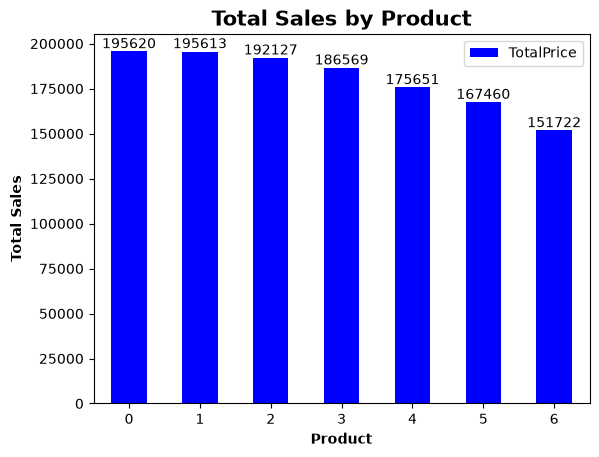

In [19]:
plt.figure(figsize=(8,6))
x=Product_Sales.plot(kind='bar',color='b')
plt.bar_label(x.containers[0])
plt.title('Total Sales by Product',fontsize=15,fontweight='bold')
plt.xlabel('Product',fontweight='bold')
plt.ylabel('Total Sales',fontweight='bold')
plt.xticks(rotation=0)
plt.show()

### 12 Payment Method Analysis

#### Payment Method Count

In [20]:
df['PaymentMethod'].value_counts().reset_index()

,PaymentMethod,count
0,Online,258
1,Cash,246
2,Credit Card,234
3,Debit Card,232
4,Gift Card,230


#### Payment Method Chart

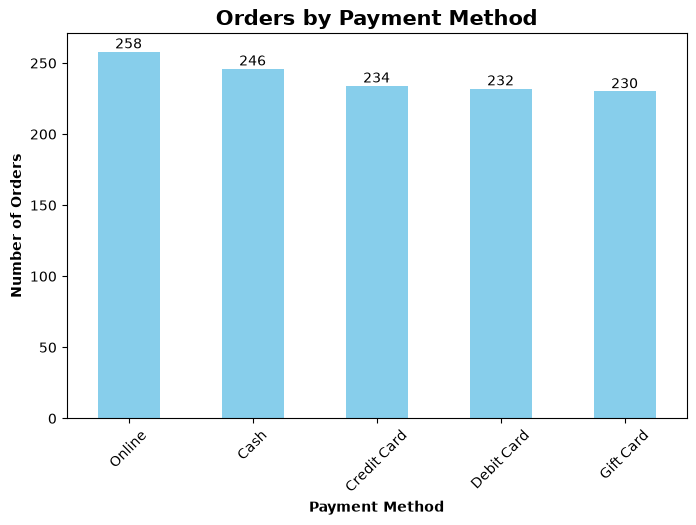

In [21]:
plt.figure(figsize=(8,5))
x=df['PaymentMethod'].value_counts().plot(kind='bar',color='skyblue')
plt.bar_label(x.containers[0])
plt.title('Orders by Payment Method',fontsize=15,fontweight='bold')
plt.xlabel('Payment Method',fontweight='bold')
plt.ylabel('Number of Orders',fontweight='bold')
plt.xticks(rotation=45)
plt.show()

### 13. Order Status Analysis

#### Order Status

In [22]:
df['OrderStatus'].value_counts().reset_index()

,OrderStatus,count
0,Cancelled,250
1,Returned,247
2,Pending,237
3,Shipped,235
4,Delivered,231


#### Order Status Chart

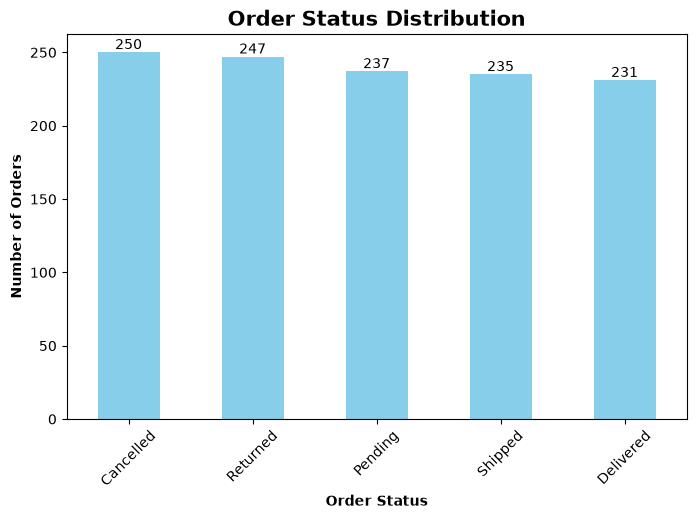

In [23]:
plt.figure(figsize=(8,5))
x=df['OrderStatus'].value_counts().plot(kind='bar',color='skyblue')
plt.bar_label(x.containers[0])
plt.title('Order Status Distribution',fontsize=15,fontweight='bold')
plt.xlabel('Order Status',fontweight='bold')
plt.ylabel('Number of Orders',fontweight='bold')
plt.xticks(rotation=45)
plt.show()

### 14. Coupon Analysis

#### Coupon Count

In [24]:
df['CouponCode'].value_counts().reset_index()

,CouponCode,count
0,FREESHIP,313
1,No Coupon,309
2,WINTER15,292
3,SAVE10,286


#### Coupon Chart

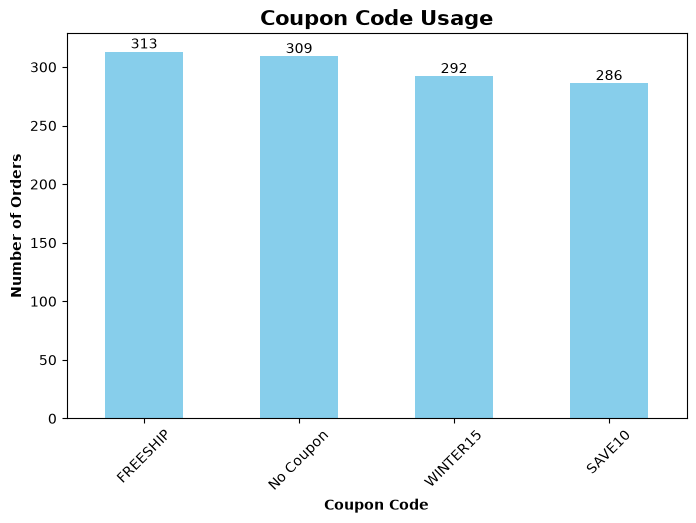

In [25]:
plt.figure(figsize=(8,5))
x=df['CouponCode'].value_counts().plot(kind='bar',color='skyblue')
plt.bar_label(x.containers[0])
plt.title('Coupon Code Usage',fontsize=15,fontweight='bold')
plt.xlabel('Coupon Code',fontweight='bold')
plt.ylabel('Number of Orders',fontweight='bold')
plt.xticks(rotation=45)
plt.show()

### 15. Referral Source Analysis

#### Referral Source Count

In [26]:
df['ReferralSource'].value_counts().reset_index()

,ReferralSource,count
0,Instagram,259
1,Email,250
2,Google,241
3,Facebook,228
4,Referral,222


#### Referral Source Chart

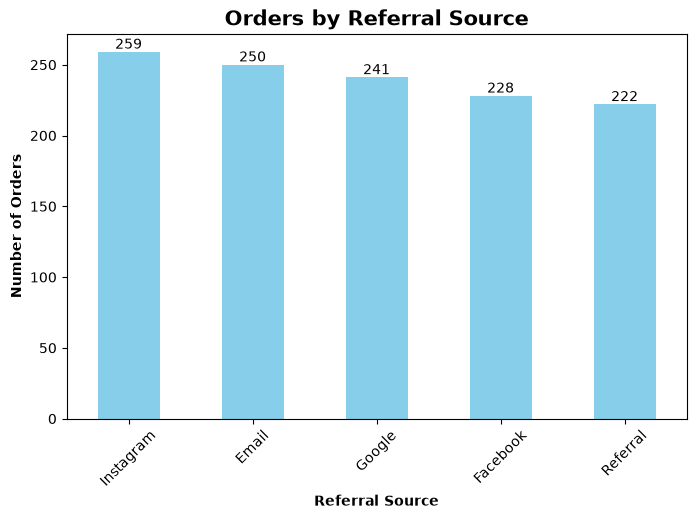

In [27]:
plt.figure(figsize=(8,5))
x=df['ReferralSource'].value_counts().plot(kind='bar',color='skyblue')
plt.bar_label(x.containers[0])
plt.title('Orders by Referral Source',fontsize=15,fontweight='bold')
plt.xlabel('Referral Source',fontweight='bold')
plt.ylabel('Number of Orders',fontweight='bold')
plt.xticks(rotation=45)
plt.show()

### 16. Year-wise Sales

In [28]:
Year_Sales=df.groupby('Year')['TotalPrice'].sum().reset_index()
Year_Sales

,Year,TotalPrice
0,2023,552643.24
1,2024,480235.87
2,2025,231882.85


#### Year-wise Sales Chart

<Figure size 800x500 with 0 Axes>

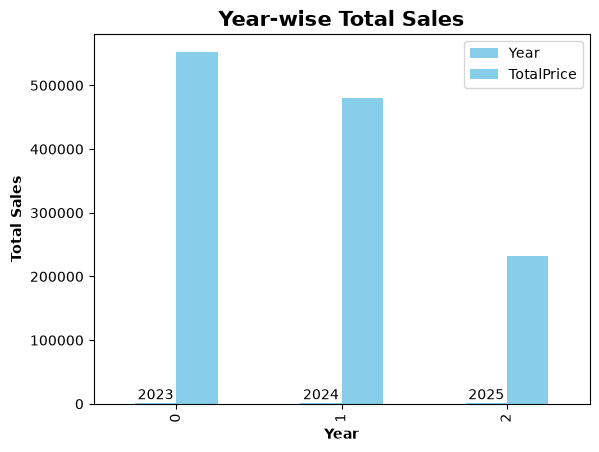

In [29]:
plt.figure(figsize=(8,5))
x=Year_Sales.plot(kind='bar',color='skyblue')
plt.bar_label(x.containers[0])
plt.title('Year-wise Total Sales',fontsize=15,fontweight='bold')
plt.xlabel('Year',fontweight='bold')
plt.ylabel('Total Sales',fontweight='bold')
plt.show()

## 17. Month-wise Sales

In [30]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

Month_Sales = df.groupby('Month')['TotalPrice'].sum().reindex(month_order)
Month_Sales.reset_index()

,Month,TotalPrice
0,January,124313.23
1,February,112344.78
2,March,123840.93
3,April,109186.05
4,May,135142.59
5,June,170616.13
6,July,85784.64
7,August,86343.21
8,September,69321.65
9,October,89834.82


#### Month-wise Sales Chart

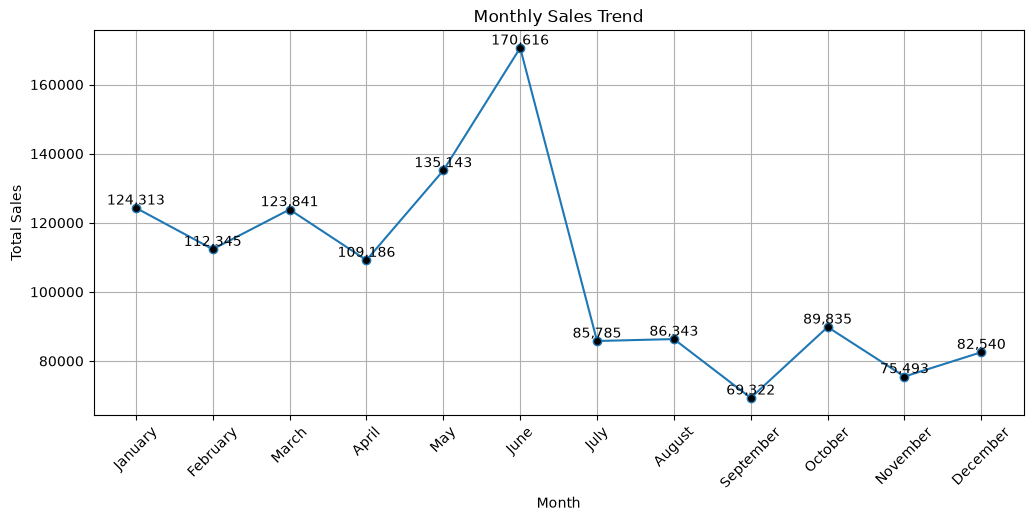

In [39]:
plt.figure(figsize=(12,5))

plt.plot(Month_Sales.index, Month_Sales.values, marker='o',markerfacecolor='k')

for x, y in zip(Month_Sales.index, Month_Sales.values):
    plt.text(x, y, f'{y:,.0f}', ha='center', va='bottom', fontsize=10,color='black')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### 18. Day-wise Analysis

In [32]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']    
Day_Orders=df['Day'].value_counts().reindex(day_order)
Day_Orders.reset_index()

,Day,count
0,Monday,174
1,Tuesday,165
2,Wednesday,163
3,Thursday,166
4,Friday,174
5,Saturday,172
6,Sunday,186


#### Day-wise Chart

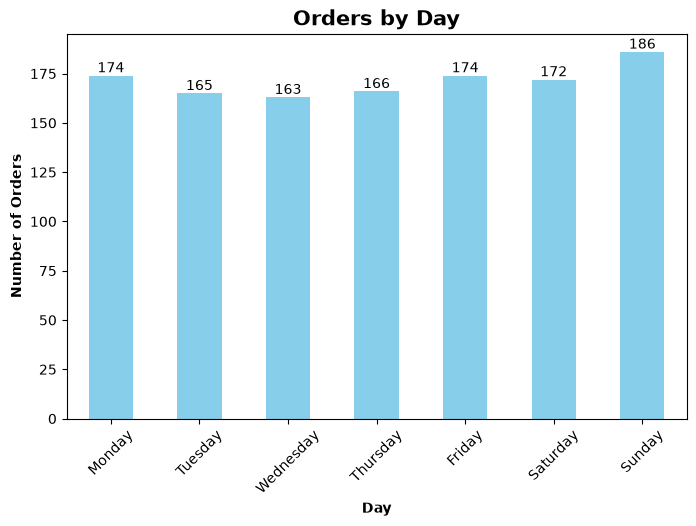

In [33]:
plt.figure(figsize=(8,5))
x=Day_Orders.plot(kind='bar',color='skyblue')
plt.bar_label(x.containers[0])
plt.title('Orders by Day',fontsize=15,fontweight='bold')
plt.xlabel('Day',fontweight='bold')
plt.ylabel('Number of Orders',fontweight='bold')
plt.xticks(rotation=45)
plt.show()

### 19. Correlation Analysis

In [34]:
corr = df.select_dtypes(include='number').corr()

corr

,Quantity,UnitPrice,ItemsInCart,TotalPrice,Year
Quantity,1.000000,0.014553,0.650061,0.615251,-0.033229
UnitPrice,0.014553,1.000000,0.000602,0.717081,-0.002233
ItemsInCart,0.650061,0.000602,1.000000,0.392540,-0.050464
TotalPrice,0.615251,0.717081,0.392540,1.000000,-0.036174
Year,-0.033229,-0.002233,-0.050464,-0.036174,1.000000


#### Correlation Heatmap

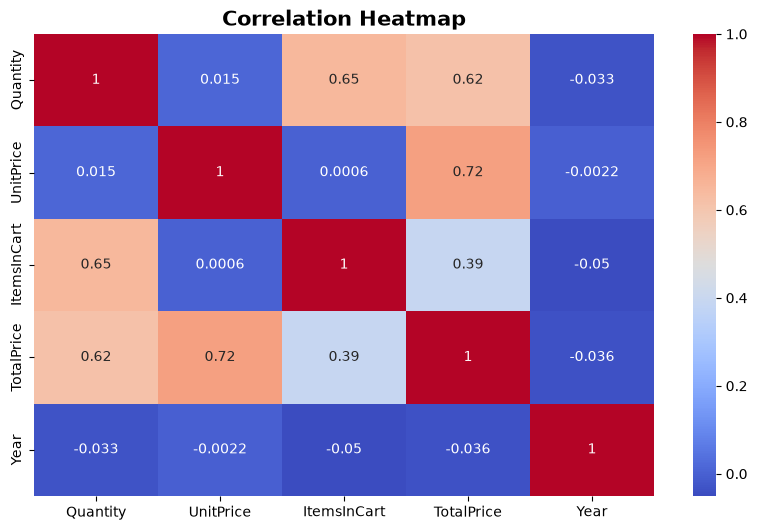

In [35]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap',fontsize=15,fontweight='bold')
plt.show()

### 20. Quantity vs Total Price

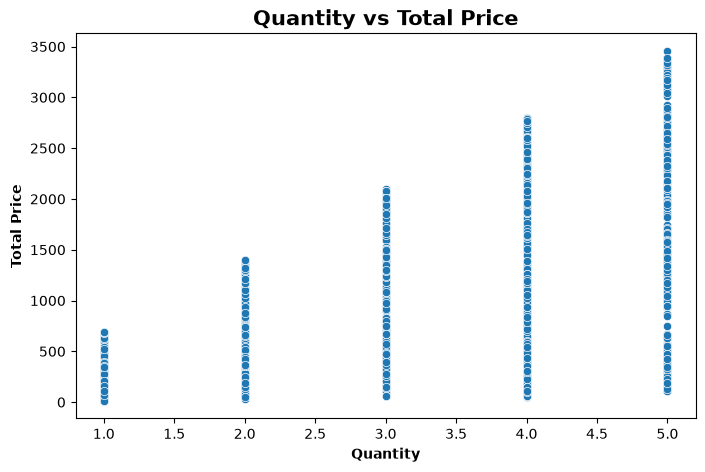

In [36]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Quantity',
    y='TotalPrice'
)

plt.title('Quantity vs Total Price',fontsize=15,fontweight='bold')
plt.xlabel('Quantity',fontweight='bold')
plt.ylabel('Total Price',fontweight='bold')
plt.show()

### 21. Unit Price vs Total Price

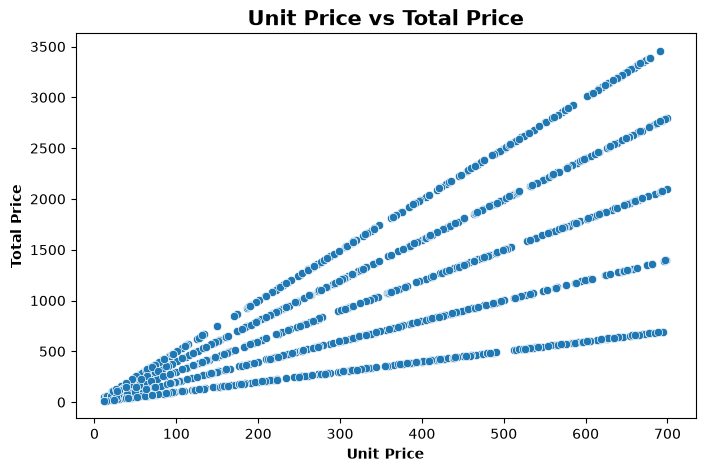

In [41]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='UnitPrice',
    y='TotalPrice'
)

plt.title('Unit Price vs Total Price',fontsize=15,fontweight='bold')
plt.xlabel('Unit Price',fontweight='bold')
plt.ylabel('Total Price',fontweight='bold')
plt.show()

### 22. Top 5 Products by Sales

In [45]:
Top_Products_Sales=df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False).head(5).reset_index()
Top_Products_Sales

,Product,TotalPrice
0,Chair,195620.11
1,Printer,195612.61
2,Laptop,192126.56
3,Tablet,186568.95
4,Monitor,175651.41


#### Top 5 Products by Sales Chart

<Figure size 800x500 with 0 Axes>

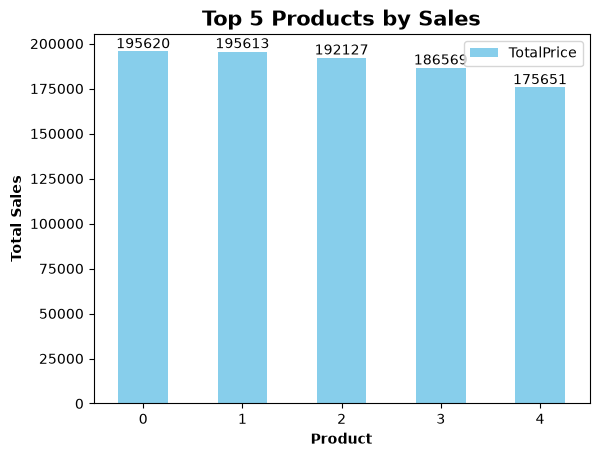

In [50]:
plt.figure(figsize=(8,5))
x=Top_Products_Sales.plot(kind='bar',color='skyblue')
plt.bar_label(x.containers[0])
plt.title('Top 5 Products by Sales',fontsize=15,fontweight='bold')
plt.xlabel('Product',fontweight='bold')
plt.ylabel('Total Sales',fontweight='bold')
plt.xticks(rotation=0)
plt.show()

### 23. Highest and Lowest Sales

#### Highest

In [55]:
High_Sales=df['TotalPrice'].max()
print(High_Sales)

3456.4


#### Lowest

In [56]:
Low_Sales=df['TotalPrice'].min()
print(Low_Sales)

11.39


#### Average

In [57]:
Avg_Sales=df['TotalPrice'].mean()
print(Avg_Sales)

1053.9683


#### Median

In [58]:
Med=df['TotalPrice'].median()
print(Med)

823.615


## Key Observations